Analyse de la Valeur Client (Segmentation RFM)
Objectif : Classer les clients en catégories (VIP, Réguliers, À risque, Perdus) selon leur comportement d'achat.

Récence (R) : Date de la dernière commande.

Fréquence (F) : Nombre total de commandes.

Montant (M) : Chiffre d'affaires total généré.

Extraction des données RFM...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\salma\AppData\Local\Temp\ipykernel_19548\1478142117.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rfm, x='Segment', palette='viridis', order=order_list)


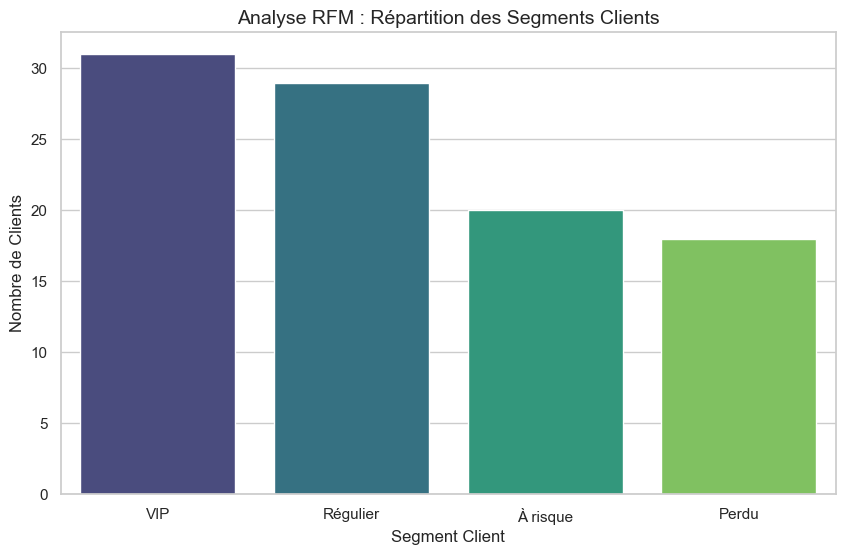

Analyse terminée. Image sauvegardée dans : ..\visualisations\rfm_segmentation.png


In [2]:
import sys
import os
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION DU CHEMIN
# Permet d'importer ta fonction de connexion depuis le dossier src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.analysis.connection import get_db_data 

# 2. EXTRACTION DES DONNÉES DEPUIS MYSQL
print("Extraction des données RFM...")
query = """
    SELECT 
        customerNumber,
        MAX(orderDate) as last_order_date,
        COUNT(orderNumber) as frequency,
        SUM(quantityOrdered * priceEach) as monetary
    FROM orders
    JOIN orderdetails USING (orderNumber)
    GROUP BY customerNumber
"""
df_rfm = get_db_data(query)

# Conversion de la date
df_rfm['last_order_date'] = pd.to_datetime(df_rfm['last_order_date'])

# 3. CALCUL DE LA RÉCENCE
# On définit une date de référence (lendemain de la dernière commande de la base)
ref_date = df_rfm['last_order_date'].max() + dt.timedelta(days=1)
df_rfm['recency'] = (ref_date - df_rfm['last_order_date']).dt.days

# 4. SCORING RFM (Utilisation des quartiles)
# Note de 1 à 4 : 4 est le meilleur score
df_rfm['R'] = pd.qcut(df_rfm['recency'], 4, labels=[4, 3, 2, 1])
df_rfm['F'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
df_rfm['M'] = pd.qcut(df_rfm['monetary'], 4, labels=[1, 2, 3, 4])

# 5. SEGMENTATION MÉTIER
def assign_segment(row):
    score = int(row['R']) + int(row['F']) + int(row['M'])
    if score >= 10:
        return 'VIP'
    elif score >= 7:
        return 'Régulier'
    elif score >= 5:
        return 'À risque'
    else:
        return 'Perdu'

df_rfm['Segment'] = df_rfm.apply(assign_segment, axis=1)

# 6. VISUALISATION
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
order_list = ['VIP', 'Régulier', 'À risque', 'Perdu']

sns.countplot(data=df_rfm, x='Segment', palette='viridis', order=order_list)

plt.title('Analyse RFM : Répartition des Segments Clients', fontsize=14)
plt.xlabel('Segment Client', fontsize=12)
plt.ylabel('Nombre de Clients', fontsize=12)

# Sauvegarde de l'image pour le rapport
save_path = os.path.join('..', 'visualisations', 'rfm_segmentation.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Analyse terminée. Image sauvegardée dans : {save_path}")

/ Analyse de la Segmentation RFM : Diagnostic et Orientations
L'objectif de cette segmentation était de transformer une base de données transactionnelle brute en une structure stratégique lisible. En croisant la récence, la fréquence et la valeur monétaire, nous obtenons une cartographie précise de la santé commerciale de ClassicModels.

--> Constats de l'Analyse (Observation Data)
L'histogramme montre une répartition que l'on pourrait qualifier de "favorablement asymétrique". Contrairement à beaucoup d'entreprises qui luttent avec une majorité de clients inactifs, ClassicModels possède une base active très robuste.

- VIP & Réguliers : Plus de 60 clients se situent dans la moitié haute du panier. Le segment VIP est, de manière assez exceptionnelle, le plus représenté. Cela témoigne d'une forte rétention historique et d'un catalogue produit qui incite à la récurrence d'achat.

- À risque : Avec 20 clients entrant dans une phase de dormance, nous observons un point de bascule. Ces clients ont déjà prouvé leur intérêt pour la marque par le passé ; leur glissement vers ce segment est souvent le signe d'une pression concurrentielle accrue ou d'un manque de sollicitation marketing.

- Perdus : Ce groupe de 18 clients représente l'érosion naturelle. Bien que non négligeable, il reste proportionnellement inférieur aux segments générateurs de valeur.